In [1]:
import zipfile
import os
with zipfile.ZipFile("Dirty Data sales archive (3).zip") as z:
  print(z.namelist())
  z.extractall()


['retail_store_sales.csv']


In [3]:
import pandas as pd
df=pd.read_csv("retail_store_sales.csv")
df.columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='object')

In [9]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


# Time Series

In [12]:
df["Transaction Date"]=pd.to_datetime(df["Transaction Date"])
df.set_index("Transaction Date",inplace=True)
print(df.index)

DatetimeIndex(['2024-04-08', '2023-07-23', '2022-10-05', '2022-05-07',
               '2022-10-02', '2023-11-30', '2023-06-10', '2024-04-02',
               '2023-04-26', '2024-03-14',
               ...
               '2024-09-06', '2023-05-09', '2023-03-28', '2022-06-11',
               '2024-05-13', '2023-09-03', '2022-08-12', '2024-08-24',
               '2023-12-30', '2022-08-06'],
              dtype='datetime64[ns]', name='Transaction Date', length=12575, freq=None)


In [8]:
df.shape

(12575, 11)

#🔰 STEP 2: Initial Data Inspection

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [5]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [6]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


Check unique values

In [16]:
df['Transaction ID'].unique()[:10]


array(['TXN_6867343', 'TXN_3731986', 'TXN_9303719', 'TXN_9458126',
       'TXN_4575373', 'TXN_7482416', 'TXN_3652209', 'TXN_1372952',
       'TXN_9728486', 'TXN_2722661'], dtype=object)

In [17]:
df.sample(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Discount Applied
Transaction Date,,,,,,,,,,
2022-05-28,TXN_4585670,CUST_03,Food,Item_21_FOOD,35.0,8.0,280.0,Digital Wallet,Online,True
2022-05-02,TXN_1676610,CUST_03,Patisserie,Item_16_PAT,27.5,10.0,275.0,Digital Wallet,Online,True
2023-02-03,TXN_8892083,CUST_11,Food,Item_11_FOOD,20.0,8.0,160.0,Cash,In-store,False
2023-10-04,TXN_8424740,CUST_13,Furniture,Item_10_FUR,18.5,7.0,129.5,Credit Card,In-store,NaN
2022-01-16,TXN_4799944,CUST_06,Furniture,Item_15_FUR,26.0,6.0,156.0,Digital Wallet,In-store,False
2024-09-25,TXN_4515512,CUST_11,Electric household essentials,Item_20_EHE,33.5,5.0,167.5,Credit Card,Online,False
2022-05-30,TXN_8423309,CUST_16,Computers and electric accessories,Item_3_CEA,8.0,9.0,72.0,Credit Card,Online,False
2023-10-25,TXN_9440172,CUST_20,Beverages,Item_25_BEV,41.0,9.0,369.0,Credit Card,In-store,False
2024-09-03,TXN_8077906,CUST_21,Milk Products,Item_24_MILK,39.5,4.0,158.0,Cash,Online,NaN


Check date range

In [18]:
print(df.index.min(), df.index.max())

2022-01-01 00:00:00 2025-01-18 00:00:00


Check frequency

In [19]:
df.index.value_counts().head()

,count
Transaction Date,
2022-05-30,26
2023-07-17,24
2024-03-16,22
2023-06-12,22
2022-01-23,21


In [21]:
df["Item"]=df["Item"].fillna(df["Item"].mode()[0])

In [22]:
import re

def clean_Total_Spent(val):
    val = re.sub(r"[^\d]", "", str(val))  # remove symbols
    return int(val) if val else None

df['Total Spent'] = df['Total Spent'].apply(clean_Total_Spent)
df["Total Spent"].head()

,Total Spent
Transaction Date,
2024-04-08,1850.0
2023-07-23,2610.0
2022-10-05,430.0
2022-05-07,2475.0
2022-10-02,875.0


In [24]:
df["Total Spent"]=df["Total Spent"].fillna(df["Total Spent"].median())
print(df["Total Spent"])

Transaction Date
2024-04-08    1850.0
2023-07-23    2610.0
2022-10-05     430.0
2022-05-07    2475.0
2022-10-02     875.0
               ...  
2023-09-03    1520.0
2022-08-12     585.0
2024-08-24    1400.0
2023-12-30     840.0
2022-08-06     510.0
Name: Total Spent, Length: 12575, dtype: float64


In [25]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,609
Quantity,604
Total Spent,0
Payment Method,0
Location,0
Discount Applied,4199


In [29]:
df["Price Per Unit"]=df["Price Per Unit"].fillna(df["Price Per Unit"].median())
print(df["Price Per Unit"])
df["Quantity"]=df["Quantity"].fillna(df["Quantity"].median())
print(df["Quantity"])
df["Discount Applied"]=df["Discount Applied"].fillna(df["Discount Applied"].median())
print(df["Discount Applied"])

Transaction Date
2024-04-08    18.5
2023-07-23    29.0
2022-10-05    21.5
2022-05-07    27.5
2022-10-02    12.5
              ... 
2023-09-03    38.0
2022-08-12     6.5
2024-08-24    14.0
2023-12-30    14.0
2022-08-06    17.0
Name: Price Per Unit, Length: 12575, dtype: float64
Transaction Date
2024-04-08    10.0
2023-07-23     9.0
2022-10-05     2.0
2022-05-07     9.0
2022-10-02     7.0
              ... 
2023-09-03     4.0
2022-08-12     9.0
2024-08-24    10.0
2023-12-30     6.0
2022-08-06     3.0
Name: Quantity, Length: 12575, dtype: float64
Transaction Date
2024-04-08     True
2023-07-23     True
2022-10-05    False
2022-05-07      1.0
2022-10-02    False
              ...  
2023-09-03      1.0
2022-08-12    False
2024-08-24      1.0
2023-12-30     True
2022-08-06      1.0
Name: Discount Applied, Length: 12575, dtype: object


In [30]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Discount Applied,0


In [33]:
df[df["Total Spent"]<0]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Discount Applied
Transaction Date,,,,,,,,,,


# Duplicates

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.dtypes

,0
Transaction ID,object
Customer ID,object
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,object
Location,object
Discount Applied,object


Check Discount values

In [43]:
df["Discount Applied"]=df["Discount Applied"].nunique()
df["Payment Method"]=df["Payment Method"].nunique()
df["Location"]=df["Location"].nunique()
df["Item"]=df["Item"].nunique()
df["Category"]=df["Category"].nunique()
df["Customer ID"]=df["Customer ID"].nunique()
df["Transaction ID"]=df["Transaction ID"].nunique()
print(df['Discount Applied'].dtype)


int64


In [44]:
df.dtypes

,0
Transaction ID,int64
Customer ID,int64
Category,int64
Item,int64
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,int64
Location,int64
Discount Applied,int64


#🔰 STEP 6: Outlier Detection (IQR + Visualization)

Step 1: Apply IQR Method

In [45]:
def find_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"\n📊 Column: {column}")
    print(f"Q1 = {Q1}")
    print(f"Q3 = {Q3}")
    print(f"IQR = {IQR}")
    print(f"Lower Bound = {lower}")
    print(f"Upper Bound = {upper}")
    print(f"Outliers Count = {outliers.shape[0]}")
    find_outliers(df, "Price Per Unit")
find_outliers(df, "Quantity")
find_outliers(df, "Total Spent")

Streaming output truncated to the last 5000 lines.

📊 Column: Price Per Unit
Q1 = 14.0
Q3 = 32.0
IQR = 18.0
Lower Bound = -13.0
Upper Bound = 59.0
Outliers Count = 0

📊 Column: Price Per Unit
Q1 = 14.0
Q3 = 32.0
IQR = 18.0
Lower Bound = -13.0
Upper Bound = 59.0
Outliers Count = 0

📊 Column: Price Per Unit
Q1 = 14.0
Q3 = 32.0
IQR = 18.0
Lower Bound = -13.0
Upper Bound = 59.0
Outliers Count = 0

📊 Column: Price Per Unit
Q1 = 14.0
Q3 = 32.0
IQR = 18.0
Lower Bound = -13.0
Upper Bound = 59.0
Outliers Count = 0

📊 Column: Price Per Unit
Q1 = 14.0
Q3 = 32.0
IQR = 18.0
Lower Bound = -13.0
Upper Bound = 59.0
Outliers Count = 0

📊 Column: Price Per Unit
Q1 = 14.0
Q3 = 32.0
IQR = 18.0
Lower Bound = -13.0
Upper Bound = 59.0
Outliers Count = 0

📊 Column: Price Per Unit
Q1 = 14.0
Q3 = 32.0
IQR = 18.0
Lower Bound = -13.0
Upper Bound = 59.0
Outliers Count = 0

📊 Column: Price Per Unit
Q1 = 14.0
Q3 = 32.0
IQR = 18.0
Lower Bound = -13.0
Upper Bound = 59.0
Outliers Count = 0

📊 Column: Price Per Unit
Q1 

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.


KeyboardInterrupt



Boxplot (Visual)

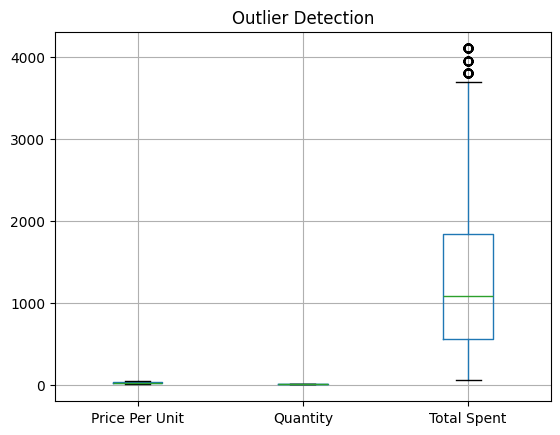

In [46]:
import matplotlib.pyplot as plt

df.boxplot(column=['Price Per Unit','Quantity','Total Spent'])
plt.title("Outlier Detection")
plt.show()

🔰 STEP 7: Feature Engineering (Sales Dataset)

In [47]:
df['Calculated_Total'] = df['Price Per Unit'] * df['Quantity']
print(df['Calculated_Total'])

Transaction Date
2024-04-08    185.0
2023-07-23    261.0
2022-10-05     43.0
2022-05-07    247.5
2022-10-02     87.5
              ...  
2023-09-03    152.0
2022-08-12     58.5
2024-08-24    140.0
2023-12-30     84.0
2022-08-06     51.0
Name: Calculated_Total, Length: 12575, dtype: float64


In [48]:
df['Discount_Impact'] = df['Total Spent'] * df['Discount Applied']
print(df["Discount_Impact"])

Transaction Date
2024-04-08    1850.0
2023-07-23    2610.0
2022-10-05     430.0
2022-05-07    2475.0
2022-10-02     875.0
               ...  
2023-09-03    1520.0
2022-08-12     585.0
2024-08-24    1400.0
2023-12-30     840.0
2022-08-06     510.0
Name: Discount_Impact, Length: 12575, dtype: float64


Purchase Size Category

In [49]:
df['Purchase_Size'] = pd.cut(
    df['Quantity'],
    bins=[0, 2, 5, 10, 100],
    labels=['Small', 'Medium', 'Large', 'Bulk']
)

Average Price per Transaction

In [51]:
df['Avg_Price'] = df['Total Spent'] / df['Quantity']
print(df["Avg_Price"])

Transaction Date
2024-04-08    185.0
2023-07-23    290.0
2022-10-05    215.0
2022-05-07    275.0
2022-10-02    125.0
              ...  
2023-09-03    380.0
2022-08-12     65.0
2024-08-24    140.0
2023-12-30    140.0
2022-08-06    170.0
Name: Avg_Price, Length: 12575, dtype: float64


In [52]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Discount Applied,Calculated_Total,Discount_Impact,Purchase_Size,Avg_Price
Transaction Date,,,,,,,,,,,,,,
2024-04-08,12575,25,8,200,18.5,10.0,1850.0,3,2,1,185.0,1850.0,Large,185.0
2023-07-23,12575,25,8,200,29.0,9.0,2610.0,3,2,1,261.0,2610.0,Large,290.0
2022-10-05,12575,25,8,200,21.5,2.0,430.0,3,2,1,43.0,430.0,Small,215.0
2022-05-07,12575,25,8,200,27.5,9.0,2475.0,3,2,1,247.5,2475.0,Large,275.0
2022-10-02,12575,25,8,200,12.5,7.0,875.0,3,2,1,87.5,875.0,Large,125.0


#🔰 STEP 8: Encoding

Step 1: Label Encoding (Purchase_Size)

In [53]:
size_map = {
    'Small': 0,
    'Medium': 1,
    'Large': 2,
    'Bulk': 3
}

df['Purchase_Size_Encoded'] = df['Purchase_Size'].map(size_map)

Step 2: One Hot Encoding

In [54]:
df = pd.get_dummies(df, columns=['Category','Item','Payment Method','Location'], drop_first=True)

In [55]:
df.head()


,Transaction ID,Customer ID,Price Per Unit,Quantity,Total Spent,Discount Applied,Calculated_Total,Discount_Impact,Purchase_Size,Avg_Price,Purchase_Size_Encoded
Transaction Date,,,,,,,,,,,
2024-04-08,12575,25,18.5,10.0,1850.0,1,185.0,1850.0,Large,185.0,2
2023-07-23,12575,25,29.0,9.0,2610.0,1,261.0,2610.0,Large,290.0,2
2022-10-05,12575,25,21.5,2.0,430.0,1,43.0,430.0,Small,215.0,0
2022-05-07,12575,25,27.5,9.0,2475.0,1,247.5,2475.0,Large,275.0,2
2022-10-02,12575,25,12.5,7.0,875.0,1,87.5,875.0,Large,125.0,2


In [56]:
df.drop(columns=['Purchase_Size'], inplace=True)

In [57]:
df.shape

(12575, 10)

#🔰 STEP 9: Feature Scaling

Continuous numeric columns

In [58]:
scale_cols = ['Price Per Unit','Quantity','Total Spent','Avg_Price','Calculated_Total']

Step 1: Apply StandardScaler

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

In [60]:
df_scaled[scale_cols].describe().round(2)

,Price Per Unit,Quantity,Total Spent,Avg_Price,Calculated_Total
count,12575.00,12575.00,12575.00,12575.00,12575.00
mean,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.75,-1.63,-1.34,-1.72,-1.36
25%,-0.89,-0.92,-0.80,-0.86,-0.81
50%,-0.03,0.16,-0.22,-0.01,-0.21
75%,0.83,0.88,0.60,0.84,0.67
max,1.68,1.59,3.04,1.70,3.03


In [61]:
df_scaled.head()

,Transaction ID,Customer ID,Price Per Unit,Quantity,Total Spent,Discount Applied,Calculated_Total,Discount_Impact,Avg_Price,Purchase_Size_Encoded
Transaction Date,,,,,,,,,,
2024-04-08,12575,25,-0.462614,1.591854,0.608979,1,0.594486,1850.0,-0.437096,2
2023-07-23,12575,25,0.539295,1.233438,1.430123,1,1.417678,2610.0,0.559025,2
2022-10-05,12575,25,-0.176354,-1.275479,-0.925262,1,-0.943584,430.0,-0.152490,0
2022-05-07,12575,25,0.396165,1.233438,1.284262,1,1.271453,2475.0,0.416722,2
2022-10-02,12575,25,-1.035133,0.516605,-0.444461,1,-0.461583,875.0,-1.006309,2


#🔰 STEP 10: Final Dataset + Summary

Step 1: Create Final Dataset

In [62]:
df_final = df_scaled.copy()

Step 2: Drop unnecessary columns

In [63]:
df_final.drop(columns=['Transaction ID','Customer ID','Purchase_Size'], inplace=True, errors='ignore')

Step 3: Final Verification (VERY IMPORTANT)

In [64]:
print("Shape:", df_final.shape)
print("Missing:", df_final.isnull().sum().sum())
print("Duplicates:", df_final.duplicated().sum())
print("Data types:\n", df_final.dtypes)
print("Sample:\n", df_final.head())

Shape: (12575, 8)
Missing: 0
Duplicates: 12086
Data types:
 Price Per Unit            float64
Quantity                  float64
Total Spent               float64
Discount Applied            int64
Calculated_Total          float64
Discount_Impact           float64
Avg_Price                 float64
Purchase_Size_Encoded    category
dtype: object
Sample:
                   Price Per Unit  Quantity  Total Spent  Discount Applied  \
Transaction Date                                                            
2024-04-08             -0.462614  1.591854     0.608979                 1   
2023-07-23              0.539295  1.233438     1.430123                 1   
2022-10-05             -0.176354 -1.275479    -0.925262                 1   
2022-05-07              0.396165  1.233438     1.284262                 1   
2022-10-02             -1.035133  0.516605    -0.444461                 1   

                  Calculated_Total  Discount_Impact  Avg_Price  \
Transaction Date                       

In [65]:
df_final.to_csv("clean_sales_data.csv", index=False)
print("✅ Clean dataset saved!")

✅ Clean dataset saved!
